# Choosing the Number of Principal Components



## Goal
Compare common criteria on the same dataset, explain why they disagree, and choose \(k\) according to the task.

## Take-home messages
1. **PCA ranks variance, not usefulness.**
2. **The goal decides the selection rule.**
3. **For prediction, validate the complete pipeline.**



In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import argrelextrema, savgol_filter

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score

BLUE   = "#00509E"
ORANGE = "#E36C32"
GREEN  = "#2E7D32"
DARK   = "#222222"
GREY   = "#667085"
LIGHT  = "#E8EEF6"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": GREY,
    "axes.labelcolor": DARK,
    "xtick.color": DARK,
    "ytick.color": DARK,
    "text.color": DARK,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

FIG_DIR = Path("pca_figures")
FIG_DIR.mkdir(exist_ok=True)

def savefig(name):
    plt.savefig(FIG_DIR / name, bbox_inches="tight", dpi=220)


## 1. Case study and PCA foundation




In [2]:
digits = load_digits()
X = digits.data
y = digits.target

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA(svd_solver="full")
pca.fit(X_std)

eigenvalues = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_
cumulative = np.cumsum(explained_ratio)
components = np.arange(1, len(eigenvalues) + 1)

print(f"Samples: {X.shape[0]}")
print(f"Original variables: {X.shape[1]}")
print(f"Numerical rank after standardization: {np.linalg.matrix_rank(X_std)}")


Samples: 1797
Original variables: 64
Numerical rank after standardization: 61


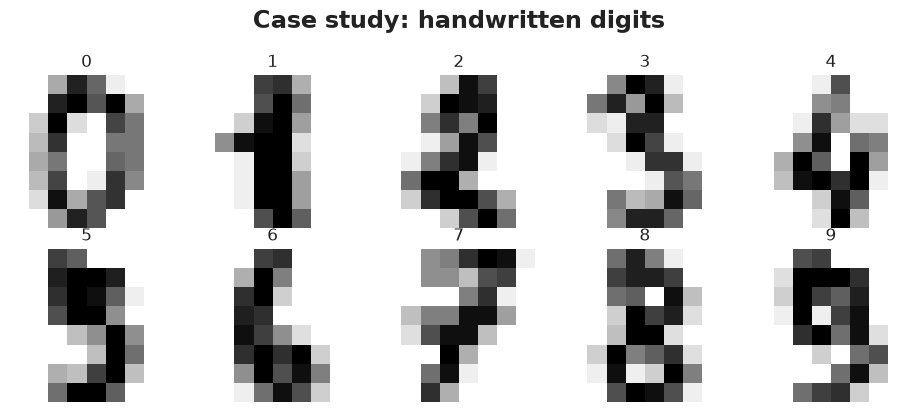

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(9.5, 4.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8, 8), cmap="gray_r")
    ax.set_title(str(y[i]), fontsize=12)
    ax.axis("off")

fig.suptitle("Case study: handwritten digits", fontsize=17, fontweight="bold")
plt.tight_layout()
savefig("digits_grid.png")
plt.show()


A concrete dataset: **1,797 handwritten digits**, **64 pixel variables**, standardized before PCA. The standardized data have numerical rank **61**, so at most 61 non-zero PCs are available.

# Take-home message 1 — PCA ranks variance, not usefulness

PCA is **unsupervised**: it finds directions with large variance in \(X\). It does not know the downstream target \(y\).

The first blocks show what PCA measures; the final block gives a simple counterexample where a low-variance direction is highly predictive.

## 2. Explained variance



In [4]:
thresholds = [0.80, 0.90, 0.95]
threshold_k = {
    t: int(np.searchsorted(cumulative, t) + 1)
    for t in thresholds
}

for t, k in threshold_k.items():
    print(f"{t:.0%} variance -> k = {k:2d}  (retained = {cumulative[k-1]:.2%})")


80% variance -> k = 21  (retained = 80.66%)
90% variance -> k = 31  (retained = 90.05%)
95% variance -> k = 40  (retained = 95.08%)


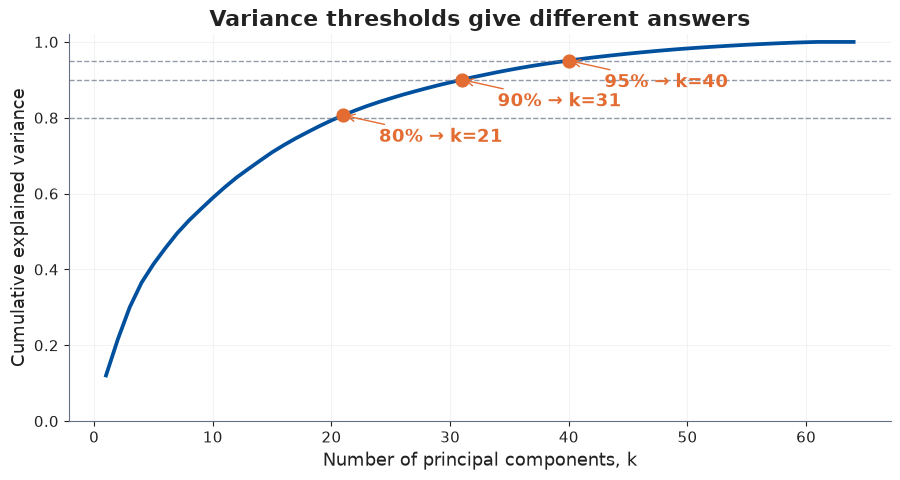

In [5]:
fig, ax = plt.subplots(figsize=(9.2, 5.0))
ax.plot(components, cumulative, lw=2.7, color=BLUE)

for t in thresholds:
    k = threshold_k[t]
    ax.axhline(t, color=GREY, lw=1, ls="--", alpha=0.7)
    ax.scatter(k, cumulative[k-1], s=85, color=ORANGE, zorder=5)
    ax.annotate(f"{int(t*100)}% → k={k}",
                xy=(k, cumulative[k-1]),
                xytext=(k+3, cumulative[k-1]-0.07),
                arrowprops=dict(arrowstyle="->", color=ORANGE),
                color=ORANGE, fontweight="bold")

ax.set(xlabel="Number of principal components, k",
       ylabel="Cumulative explained variance",
       ylim=(0, 1.02))
ax.set_title("Variance thresholds give different answers", fontweight="bold")
ax.grid(alpha=0.15)
plt.tight_layout()
savefig("cumulative_variance.png")
plt.show()


Variance accumulates gradually. There is no unique mathematical point called “enough”; a threshold must be chosen and justified.

## 3. Why high variance is not the same as relevance to \(y\)


In [6]:
# Toy example:
# x1 has very large variance but is unrelated to the class.
# x2 has much smaller variance but carries the class information.

rng = np.random.default_rng(7)
n = 500
y_toy = rng.integers(0, 2, size=n)

x1 = rng.normal(0, 10, size=n)                       # high variance, irrelevant
x2 = (2*y_toy - 1) * 0.75 + rng.normal(0, 0.18, n) # low variance, predictive
X_toy = np.c_[x1, x2]

print("Variance of x1:", np.var(x1).round(2))
print("Variance of x2:", np.var(x2).round(2))
print("Correlation |x1,y|:", abs(np.corrcoef(x1, y_toy)[0,1]).round(3))
print("Correlation |x2,y|:", abs(np.corrcoef(x2, y_toy)[0,1]).round(3))


Variance of x1: 93.59
Variance of x2: 0.61
Correlation |x1,y|: 0.021
Correlation |x2,y|: 0.975


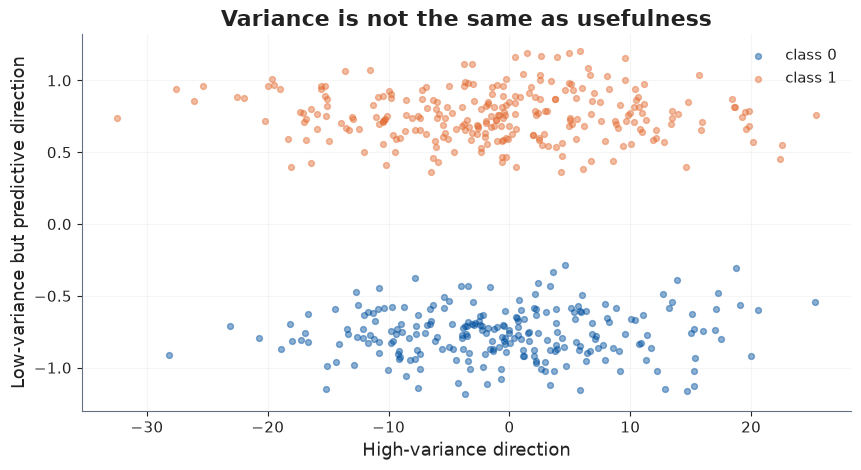

In [7]:
fig, ax = plt.subplots(figsize=(8.8, 4.9))
mask = y_toy == 0
ax.scatter(x1[mask], x2[mask], s=18, alpha=0.45, color=BLUE, label="class 0")
ax.scatter(x1[~mask], x2[~mask], s=18, alpha=0.45, color=ORANGE, label="class 1")
ax.set_xlabel("High-variance direction")
ax.set_ylabel("Low-variance but predictive direction")
ax.set_title("Variance is not the same as usefulness", fontweight="bold")
ax.legend(frameon=False)
ax.grid(alpha=0.12)
plt.tight_layout()
savefig("variance_not_usefulness.png")
plt.show()


A feature can have small variance and still separate the target classes perfectly. This is why a variance-only cutoff may discard predictive information.

# Take-home message 2 — the goal decides the selection rule

Different criteria answer different questions:

- **Cumulative variance:** how much \(X\)-variance do we keep?
- **Scree/elbow:** where does the spectrum bend?
- **Kaiser:** which standardized PCs have eigenvalue \(>1\)?
- **Reconstruction:** how much visible information is preserved?
- **Cross-validation:** how well does the downstream task perform?



## 4. Scree plot 



In [8]:
# Distance-to-line elbow on normalized axes
xn = (components - components.min()) / (components.max() - components.min())
yn = (eigenvalues - eigenvalues.min()) / (eigenvalues.max() - eigenvalues.min())

A = np.array([xn[0], yn[0]])
B = np.array([xn[-1], yn[-1]])
P = np.c_[xn, yn]

AB = B - A
dist = np.abs(np.cross(AB, P - A) / np.linalg.norm(AB))
k_line = int(components[np.argmax(dist)])

def kneedle_convex_decreasing(x, y, S=1.0):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    xn = (x - x.min()) / (x.max() - x.min())
    yn = (y - y.min()) / (y.max() - y.min())

    # Convert convex-decreasing curve to the Kneedle difference curve
    diff = (yn.max() - yn) - xn

    maxima = argrelextrema(diff, np.greater_equal)[0]
    minima = argrelextrema(diff, np.less_equal)[0]
    thresholds = diff[maxima] - S * np.diff(xn).mean()

    maxima_set = set(maxima.tolist())
    minima_set = set(minima.tolist())
    active = False
    m = 0

    for i in range(len(x)-1):
        if len(maxima) == 0 or i < maxima[0]:
            continue
        if i in maxima_set:
            threshold = thresholds[m]
            knee_index = i
            m += 1
            active = True
        if i in minima_set:
            active = False
        if active and diff[i+1] < threshold:
            return int(x[knee_index])
    return None

k_kneedle = kneedle_convex_decreasing(components, eigenvalues)

print("Distance-to-line elbow:", k_line)
print("Kneedle:", k_kneedle)


Distance-to-line elbow: 9
Kneedle: 13


C:\Users\jakobm\AppData\Local\Temp\ipykernel_6204\3931226191.py:10: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(AB, P - A) / np.linalg.norm(AB))


Geometric elbow: k = 9


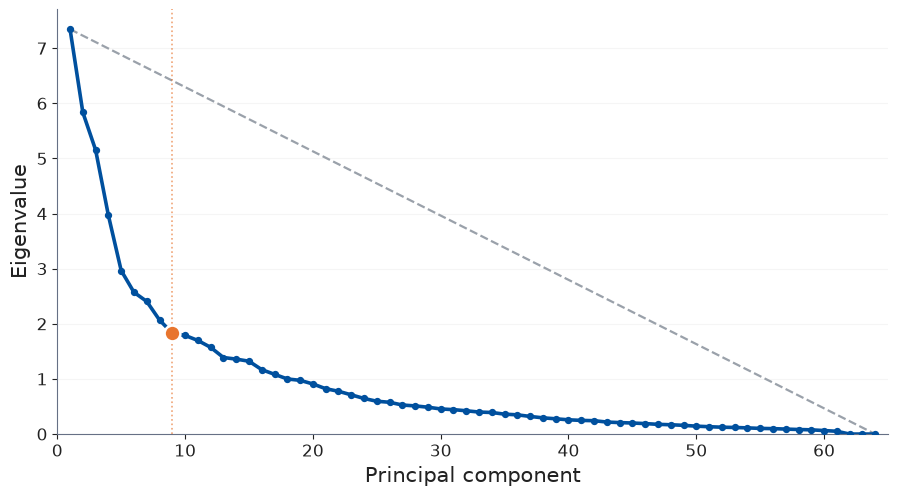

In [9]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1, len(eigenvalues) + 1)
y = np.asarray(eigenvalues)

x_n = (x - x.min()) / (x.max() - x.min())
y_n = (y - y.min()) / (y.max() - y.min())

P = np.column_stack([x_n, y_n])

A = P[0]
B = P[-1]
AB = B - A

t = ((P - A) @ AB) / (AB @ AB)
projection = A + t[:, None] * AB

distance = np.linalg.norm(P - projection, axis=1)

elbow_idx = np.argmax(distance)
k_elbow = int(x[elbow_idx])

print(f"Geometric elbow: k = {k_elbow}")

BLUE = "#00509E"
ORANGE = "#E8752E"
GREY = "#9AA1AA"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 14,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(9.2, 5.2))

ax.plot(
    x,
    y,
    color=BLUE,
    linewidth=2.6
)

ax.scatter(
    x,
    y,
    color=BLUE,
    s=18,
    zorder=3
)

ax.plot(
    [x[0], x[-1]],
    [y[0], y[-1]],
    color=GREY,
    linewidth=1.6,
    linestyle="--",
    zorder=1
)

ax.scatter(
    k_elbow,
    y[elbow_idx],
    s=130,
    color=ORANGE,
    edgecolor="white",
    linewidth=1.8,
    zorder=5
)

ax.axvline(
    k_elbow,
    color=ORANGE,
    linestyle=":",
    linewidth=1.2,
    alpha=0.65
)

ax.set_xlabel("Principal component")
ax.set_ylabel("Eigenvalue")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.12
)

ax.set_xlim(0, len(eigenvalues) + 1)
ax.set_ylim(bottom=0)

plt.tight_layout()

plt.savefig(
    "geometric_elbow.pdf",
    bbox_inches="tight"
)

plt.show()

Kneedle: 13
Kneedle index: 12


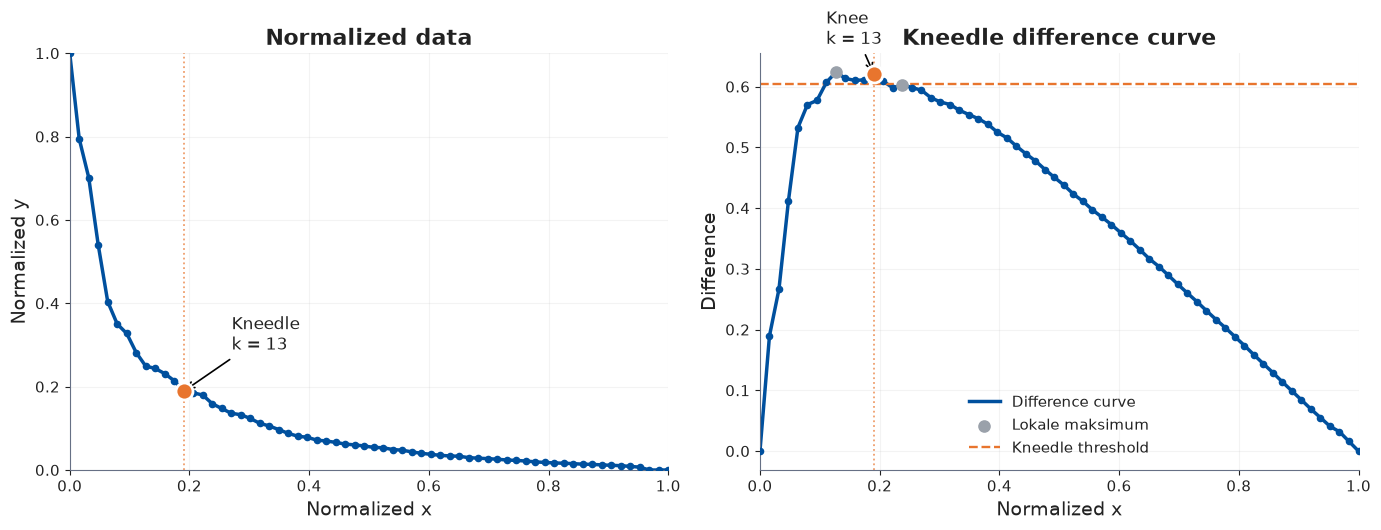

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema


# ============================================================
# KNEEDLE ILLUSTRASJON
# Samme logikk som funksjonen din
# ============================================================

x = np.asarray(components, dtype=float)
y = np.asarray(eigenvalues, dtype=float)

S = 1.0


# ------------------------------------------------------------
# 1. NORMALISERING AV BEGGE AKSER
# ------------------------------------------------------------

xn = (x - x.min()) / (x.max() - x.min())
yn = (y - y.min()) / (y.max() - y.min())


# ------------------------------------------------------------
# 2. DIFFERENCE CURVE
#
# For convex decreasing kurve:
#
# diff = (1 - y_normalized) - x_normalized
# ------------------------------------------------------------

diff = (yn.max() - yn) - xn


# ------------------------------------------------------------
# 3. LOKALE MAKSIMA OG MINIMA
# ------------------------------------------------------------

maxima = argrelextrema(
    diff,
    np.greater_equal
)[0]

minima = argrelextrema(
    diff,
    np.less_equal
)[0]


# ------------------------------------------------------------
# 4. KNEEDLE THRESHOLD
# ------------------------------------------------------------

dx = np.diff(xn).mean()

thresholds = diff[maxima] - S * dx


# ------------------------------------------------------------
# 5. FINN KNEE MED SAMME ALGORITME SOM DIN KODE
# ------------------------------------------------------------

maxima_set = set(maxima.tolist())
minima_set = set(minima.tolist())

active = False
m = 0

knee_idx = None
threshold = None
max_idx = None

for i in range(len(x) - 1):

    if len(maxima) == 0 or i < maxima[0]:
        continue

    if i in maxima_set:

        threshold = thresholds[m]
        max_idx = i

        m += 1
        active = True

    if i in minima_set:
        active = False

    if active and diff[i + 1] < threshold:

        knee_idx = max_idx
        break


# ------------------------------------------------------------
# Resultat
# ------------------------------------------------------------

if knee_idx is not None:

    k_kneedle = int(x[knee_idx])

    print("Kneedle:", k_kneedle)
    print("Kneedle index:", knee_idx)

else:

    print("Fant ikke Kneedle-punkt")


# ============================================================
# PLOTTING
# ============================================================

BLUE = "#00509E"
ORANGE = "#E8752E"
GREY = "#9AA1AA"
DARK = "#333333"


plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})


fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 5.5)
)


# ============================================================
# VENSTRE:
# NORMALISERT KURVE
# ============================================================

ax1.plot(
    xn,
    yn,
    color=BLUE,
    linewidth=2.5
)

ax1.scatter(
    xn,
    yn,
    color=BLUE,
    s=20,
    zorder=3
)


# Kneedle-punkt
if knee_idx is not None:

    ax1.scatter(
        xn[knee_idx],
        yn[knee_idx],
        s=150,
        color=ORANGE,
        edgecolor="white",
        linewidth=2,
        zorder=5
    )

    ax1.axvline(
        xn[knee_idx],
        color=ORANGE,
        linestyle=":",
        linewidth=1.3,
        alpha=0.7
    )

    ax1.annotate(
        f"Kneedle\nk = {k_kneedle}",
        xy=(xn[knee_idx], yn[knee_idx]),
        xytext=(
            xn[knee_idx] + 0.08,
            yn[knee_idx] + 0.10
        ),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.2
        ),
        fontsize=12
    )


ax1.set_title(
    "Normalized data",
    fontweight="bold"
)

ax1.set_xlabel(
    "Normalized x"
)

ax1.set_ylabel(
    "Normalized y"
)

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

ax1.grid(alpha=0.15)


# ============================================================
# HØYRE:
# DIFFERENCE CURVE
# ============================================================

ax2.plot(
    xn,
    diff,
    color=BLUE,
    linewidth=2.5,
    label="Difference curve"
)

ax2.scatter(
    xn,
    diff,
    color=BLUE,
    s=20,
    zorder=3
)


# Vis lokale maksima
if len(maxima) > 0:

    ax2.scatter(
        xn[maxima],
        diff[maxima],
        color=GREY,
        s=65,
        zorder=4,
        label="Lokale maksimum"
    )


# Vis Kneedle maximum
if knee_idx is not None:

    ax2.scatter(
        xn[knee_idx],
        diff[knee_idx],
        s=150,
        color=ORANGE,
        edgecolor="white",
        linewidth=2,
        zorder=6
    )

    # Threshold
    ax2.axhline(
        threshold,
        color=ORANGE,
        linestyle="--",
        linewidth=1.7,
        label="Kneedle threshold"
    )

    # Vertikal linje
    ax2.axvline(
        xn[knee_idx],
        color=ORANGE,
        linestyle=":",
        linewidth=1.3,
        alpha=0.7
    )

    ax2.annotate(
        f"Knee\nk = {k_kneedle}",
        xy=(xn[knee_idx], diff[knee_idx]),
        xytext=(
            xn[knee_idx] - 0.08,
            diff[knee_idx] + 0.05
        ),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.2
        ),
        fontsize=12
    )


ax2.set_title(
    "Kneedle difference curve",
    fontweight="bold"
)

ax2.set_xlabel(
    "Normalized x"
)

ax2.set_ylabel(
    "Difference"
)

ax2.set_xlim(0, 1)

ax2.grid(alpha=0.15)

ax2.legend(frameon=False)


# Fjern øvre/høyre kant
for ax in (ax1, ax2):

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


plt.tight_layout()

plt.savefig(
    "kneedle_illustration.pdf",
    bbox_inches="tight"
)

plt.show()

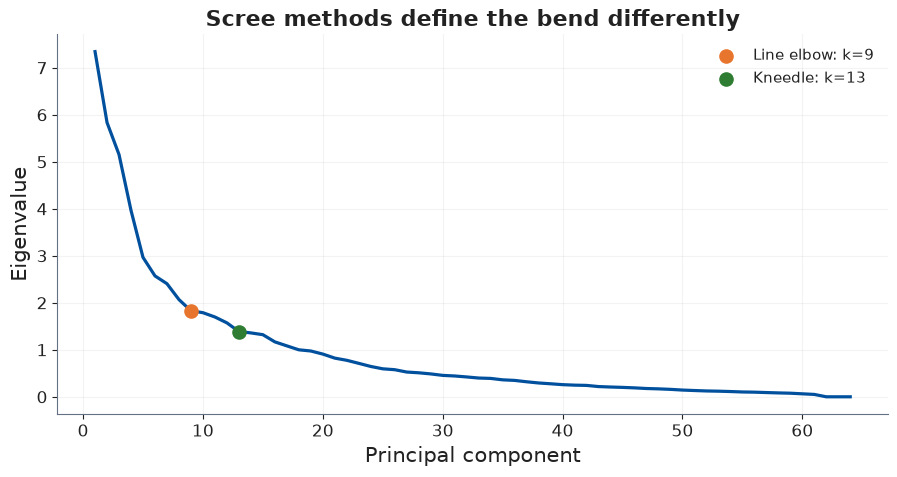

In [10]:
fig, ax = plt.subplots(figsize=(9.2, 5.0))
ax.plot(components, eigenvalues, lw=2.3, color=BLUE)
ax.scatter(k_line, eigenvalues[k_line-1], s=90, color=ORANGE, zorder=5,
           label=f"Line elbow: k={k_line}")
ax.scatter(k_kneedle, eigenvalues[k_kneedle-1], s=90, color=GREEN, zorder=5,
           label=f"Kneedle: k={k_kneedle}")

ax.set(xlabel="Principal component",
       ylabel="Eigenvalue")
ax.set_title("Scree methods define the bend differently", fontweight="bold")
ax.legend(frameon=False)
ax.grid(alpha=0.15)
plt.tight_layout()
savefig("scree_elbows.png")
plt.show()


The spectrum falls quickly at first and then flattens. An elbow is a useful heuristic, but its location depends on how “bend” is defined.

## 5. Kaiser criterion
 

In [11]:
k_kaiser = int(np.sum(eigenvalues > 1))
print("Kaiser selection:", k_kaiser)
print("Last retained eigenvalue:", round(eigenvalues[k_kaiser-1], 6))
print("First discarded eigenvalue:", round(eigenvalues[k_kaiser], 6))


Kaiser selection: 17
Last retained eigenvalue: 1.083687
First discarded eigenvalue: 0.999779


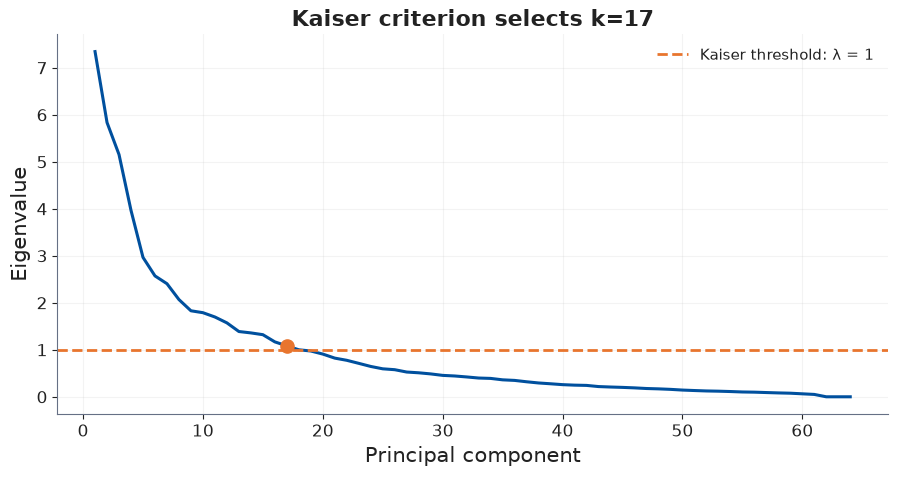

In [12]:
fig, ax = plt.subplots(figsize=(9.2, 5.0))
ax.plot(components, eigenvalues, lw=2.2, color=BLUE)
ax.axhline(1, lw=2, ls="--", color=ORANGE, label="Kaiser threshold: λ = 1")
ax.scatter(k_kaiser, eigenvalues[k_kaiser-1], s=90, color=ORANGE, zorder=5)

ax.set(xlabel="Principal component", ylabel="Eigenvalue")
ax.set_title(f"Kaiser criterion selects k={k_kaiser}", fontweight="bold")
ax.legend(frameon=False)
ax.grid(alpha=0.15)
plt.tight_layout()
savefig("kaiser.png")
plt.show()



For standardized-variable PCA, Kaiser keeps PCs with eigenvalue \(>1\). On this dataset it selects **17 PCs**. 

## 6. Reconstruction (useful when the goal is compression)



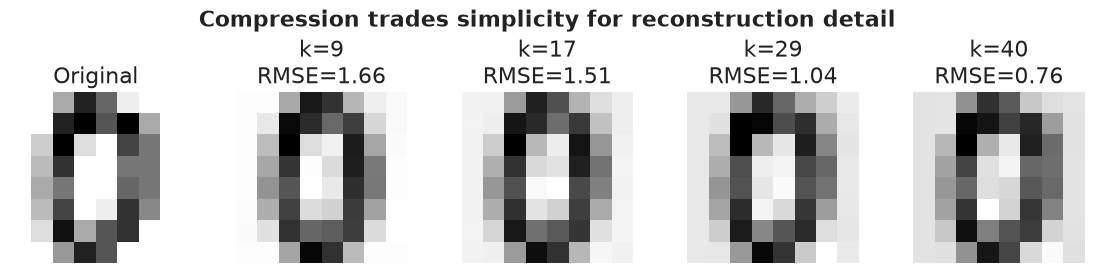

In [13]:
sample_id = 0
k_values = [9, 17, 29, 40]

fig, axes = plt.subplots(1, len(k_values)+1, figsize=(11.5, 2.8))

axes[0].imshow(X[sample_id].reshape(8, 8), cmap="gray_r")
axes[0].set_title("Original")
axes[0].axis("off")

for ax, k in zip(axes[1:], k_values):
    pca_k = PCA(n_components=k).fit(X_std)
    z = pca_k.transform(X_std[[sample_id]])
    X_std_rec = pca_k.inverse_transform(z)
    X_rec = scaler.inverse_transform(X_std_rec)[0]

    rmse = np.sqrt(np.mean((X_rec - X[sample_id])**2))
    ax.imshow(X_rec.reshape(8, 8), cmap="gray_r")
    ax.set_title(f"k={k}\nRMSE={rmse:.2f}")
    ax.axis("off")

fig.suptitle("Compression trades simplicity for reconstruction detail",
             fontsize=16, fontweight="bold")
plt.tight_layout()
savefig("reconstruction.png")
plt.show()


Small \(k\) gives stronger compression but loses visible detail. Larger \(k\) preserves the original image more closely. 

# Take-home message 3 — for prediction, validate the complete pipeline


## 8. Leakage-safe cross-validation



In [14]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score


digits = load_digits()

X = digits.data
target = digits.target


def run_full_repeated_cv(X, target):
    if len(X) != len(target):
        raise ValueError(
            f"X and target have different lengths: "
            f"{len(X)} vs {len(target)}"
        )

    max_k = min(X.shape[1], X.shape[0] - 1)

    cv = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=3,
        random_state=42
    )

    rows = []

    for k in range(1, max_k + 1):
        pipe = Pipeline([
            ("scale", StandardScaler()),
            ("pca", PCA(n_components=k)),
            ("model", LogisticRegression(
                max_iter=2000,
                solver="lbfgs"
            ))
        ])

        scores = cross_val_score(
            pipe,
            X,
            target,
            cv=cv,
            scoring="accuracy",
            n_jobs=-1
        )

        rows.append({
            "k": k,
            "mean_accuracy": scores.mean(),
            "sd": scores.std(ddof=1),
            "se": scores.std(ddof=1) / np.sqrt(len(scores))
        })

    return pd.DataFrame(rows)


print("X shape:", X.shape)
print("target shape:", target.shape)

cache = Path("pca_cv_results_cached.csv")

if cache.exists():
    cv_results = pd.read_csv(cache)
    print("Loaded cached CV results.")
else:
    print("Cache not found — recomputing full repeated CV.")
    cv_results = run_full_repeated_cv(X, target)
    cv_results.to_csv(cache, index=False)
    print("CV results saved to cache.")

cv_results.head()

X shape: (1797, 64)
target shape: (1797,)
Cache not found — recomputing full repeated CV.
CV results saved to cache.


,k,mean_accuracy,sd,se
0,1,0.353376,0.022408,0.005786
1,2,0.543130,0.014245,0.003678
2,3,0.694869,0.020044,0.005175
3,4,0.793737,0.019524,0.005041
4,5,0.810989,0.023935,0.006180


In [15]:
best_idx = cv_results["mean_accuracy"].idxmax()
best_row = cv_results.loc[best_idx]
k_best = int(best_row["k"])
best_mean = best_row["mean_accuracy"]
best_se = best_row["se"]

one_se_threshold = best_mean - best_se
k_one_se = int(
    cv_results.loc[
        cv_results["mean_accuracy"] >= one_se_threshold,
        "k"
    ].min()
)

one_se_acc = float(
    cv_results.loc[cv_results["k"] == k_one_se, "mean_accuracy"].iloc[0]
)

print(f"First maximum: k={k_best}, accuracy={best_mean:.3%}")
print(f"One-SE choice: k={k_one_se}, accuracy={one_se_acc:.3%}")
print(f"Accuracy difference: {(best_mean-one_se_acc)*100:.3f} percentage points")


First maximum: k=53, accuracy=97.088%
One-SE choice: k=45, accuracy=97.032%
Accuracy difference: 0.056 percentage points


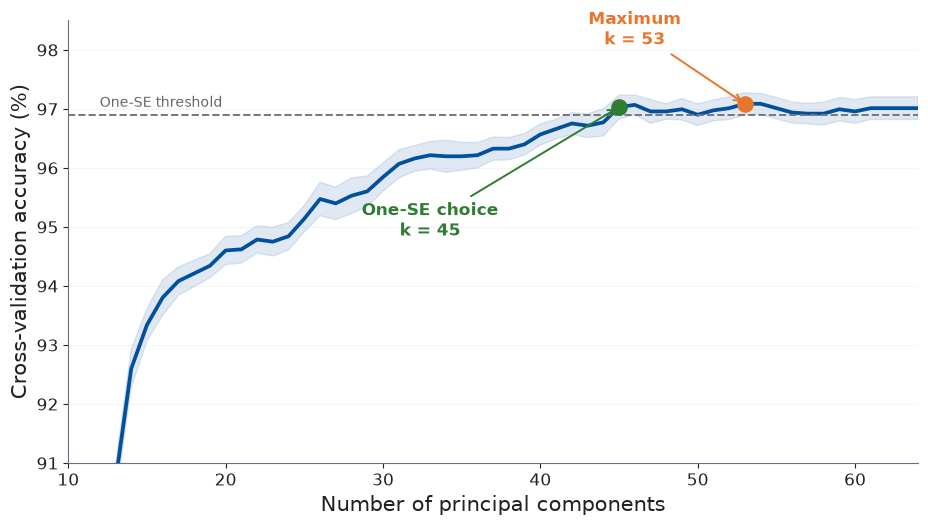

Maximum k = 53
Maximum accuracy = 0.9709
SE at maximum = 0.0019
One-SE threshold = 0.9690
One-SE choice = 45


In [16]:
import numpy as np
import matplotlib.pyplot as plt

best_idx = cv_results["mean_accuracy"].idxmax()

best_k = int(cv_results.loc[best_idx, "k"])
best_mean = cv_results.loc[best_idx, "mean_accuracy"]
best_se = cv_results.loc[best_idx, "se"]

threshold = best_mean - best_se

k_one_se = int(
    cv_results.loc[
        cv_results["mean_accuracy"] >= threshold,
        "k"
    ].min()
)

one_se_mean = cv_results.loc[
    cv_results["k"] == k_one_se,
    "mean_accuracy"
].iloc[0]

k = cv_results["k"].to_numpy()
mean = cv_results["mean_accuracy"].to_numpy() * 100
se = cv_results["se"].to_numpy() * 100

fig, ax = plt.subplots(figsize=(9.5, 5.5))

ax.plot(
    k,
    mean,
    color="#00509E",
    linewidth=2.7
)

ax.fill_between(
    k,
    mean - se,
    mean + se,
    color="#00509E",
    alpha=0.12
)

ax.axhline(
    threshold * 100,
    color="#777777",
    linestyle="--",
    linewidth=1.4
)

ax.scatter(
    best_k,
    best_mean * 100,
    s=120,
    color="#E8752E",
    zorder=5
)

ax.scatter(
    k_one_se,
    one_se_mean * 100,
    s=120,
    color="#2E7D32",
    zorder=5
)

ax.annotate(
    f"Maximum\nk = {best_k}",
    xy=(best_k, best_mean * 100),
    xytext=(46, 98.0),
    ha="center",
    va="bottom",
    color="#E8752E",
    fontweight="bold",
    fontsize=12,
    arrowprops=dict(
        arrowstyle="->",
        color="#E8752E",
        lw=1.4
    )
)

ax.annotate(
    f"One-SE choice\nk = {k_one_se}",
    xy=(k_one_se, one_se_mean * 100),
    xytext=(33, 95.45),
    ha="center",
    va="top",
    color="#2E7D32",
    fontweight="bold",
    fontsize=12,
    arrowprops=dict(
        arrowstyle="->",
        color="#2E7D32",
        lw=1.4
    )
)

ax.text(
    12,
    threshold * 100 + 0.08,
    "One-SE threshold",
    color="#666666",
    fontsize=10,
    va="bottom"
)

ax.set_xlim(10, 64)
ax.set_ylim(91, 98.5)

ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cross-validation accuracy (%)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.12)

plt.tight_layout()
plt.show()

print(f"Maximum k = {best_k}")
print(f"Maximum accuracy = {best_mean:.4f}")
print(f"SE at maximum = {best_se:.4f}")
print(f"One-SE threshold = {threshold:.4f}")
print(f"One-SE choice = {k_one_se}")

# Final decision — put all rules on one page

**What should we see?**  
The disagreement is the main result. Different methods select different \(k\) because they optimize different definitions of “enough.”

In [17]:
method_summary = pd.DataFrame({
    "Method": [
        "Line elbow",
        "Kneedle",
        "Kaiser",
        "80% variance",
        "90% variance",
        "95% variance",
        "CV one-SE",
        "CV maximum",
        "Numerical rank"
    ],
    "Question answered": [
        "Where is the geometric bend?",
        "Where is the algorithmic knee?",
        "Which λ are > 1?",
        "How many retain 80% variance?",
        "How many retain 90% variance?",
        "How many retain 95% variance?",
        "Simplest near-optimal predictor?",
        "Highest predictive accuracy?",
        "How many non-zero directions?"
    ],
    "k": [
        k_line,
        k_kneedle,
        k_kaiser,
        threshold_k[0.80],
        threshold_k[0.90],
        threshold_k[0.95],
        k_one_se,
        k_best,
        int(np.linalg.matrix_rank(X_std))
    ]
})

method_summary


,Method,Question answered,k
0,Line elbow,Where is the geometric bend?,9
1,Kneedle,Where is the algorithmic knee?,13
2,Kaiser,Which λ are > 1?,17
3,80% variance,How many retain 80% variance?,21
4,90% variance,How many retain 90% variance?,31
5,95% variance,How many retain 95% variance?,40
6,CV one-SE,Simplest near-optimal predictor?,45
7,CV maximum,Highest predictive accuracy?,53
8,Numerical rank,How many non-zero directions?,61


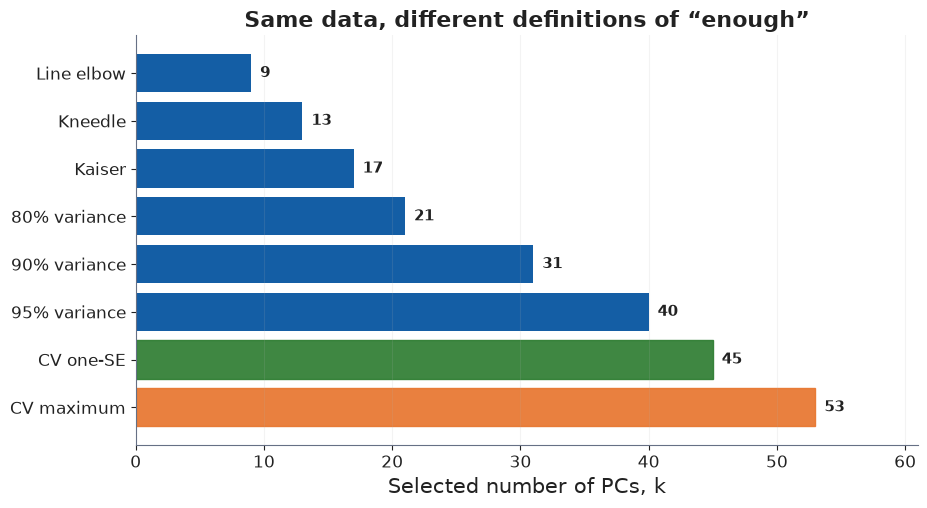

In [18]:
plot_df = method_summary.iloc[:8].copy()

fig, ax = plt.subplots(figsize=(9.5, 5.3))
bars = ax.barh(plot_df["Method"], plot_df["k"], color=BLUE, alpha=0.92)

# Highlight the predictive recommendation and predictive maximum.
for i, method in enumerate(plot_df["Method"]):
    if method == "CV one-SE":
        bars[i].set_color(GREEN)
    elif method == "CV maximum":
        bars[i].set_color(ORANGE)

for bar, k in zip(bars, plot_df["k"]):
    ax.text(k + 0.7, bar.get_y() + bar.get_height()/2, str(k),
            va="center", fontsize=11, fontweight="bold")

ax.invert_yaxis()
ax.set_xlabel("Selected number of PCs, k")
ax.set_title("Same data, different definitions of “enough”", fontweight="bold")
ax.set_xlim(0, max(plot_df["k"]) + 8)
ax.grid(axis="x", alpha=0.15)
plt.tight_layout()
savefig("method_comparison.png")
plt.show()
